<a href="https://colab.research.google.com/github/ms7212441-lang/ML-/blob/main/ML_expt_no_7_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Points: [ 1  2  3  8  9 10]
Clusters: [0 0 0 1 1 1]
Means: [2. 9.]


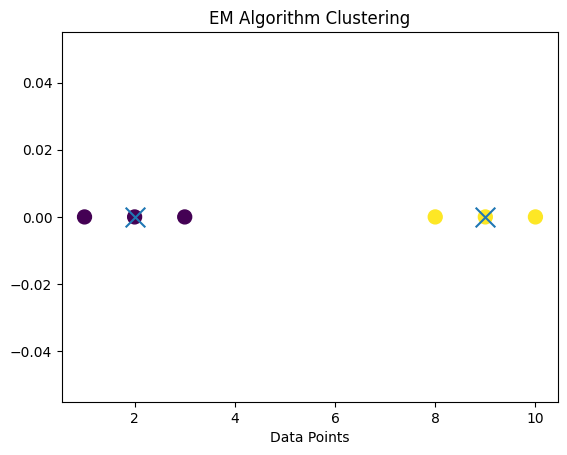

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt


# Sample data
data = np.array([1, 2, 3, 8, 9, 10])
print("Data Points:",data)


# Number of clusters
k = 2


# Initialize parameters
means = np.random.choice(data, k)
variances = np.ones(k)
weights = np.ones(k) / k


iterations = 10


for iteration in range(iterations):


   # E-step
   resp = np.zeros((len(data), k))


   for j in range(k):
       resp[:, j] = weights[j] * norm.pdf(data, means[j], np.sqrt(variances[j]))


   resp = resp / resp.sum(axis=1, keepdims=True)


   # M-step
   Nk = resp.sum(axis=0)


   means = (resp * data[:, np.newaxis]).sum(axis=0) / Nk
   variances = (resp * (data[:, np.newaxis] - means)**2).sum(axis=0) / Nk
   weights = Nk / len(data)


# Assign clusters
clusters = np.argmax(resp, axis=1)


print("Clusters:", clusters)
print("Means:", means)


# Plot clusters
plt.scatter(data, np.zeros_like(data), c=clusters, s=100)
plt.scatter(means, np.zeros_like(means), marker='x', s=200)
plt.title("EM Algorithm Clustering")
plt.xlabel("Data Points")
plt.show()


## EM Algorithm for Clustering

### Algorithm Steps:

1.  **Initialization**: Randomly initialize the mean, variance, and weight for each of the `k` clusters.
2.  **Expectation (E-step)**:
    *   For each data point, calculate the probability (responsibility) that it belongs to each cluster, given the current cluster parameters.
    *   This is typically done using a probability density function (e.g., Gaussian).
3.  **Maximization (M-step)**:
    *   Update the parameters (mean, variance, and weight) for each cluster using the responsibilities calculated in the E-step.
    *   The new parameters are weighted averages, with higher responsibilities contributing more to the update.
4.  **Iteration**: Repeat the E-step and M-step for a fixed number of iterations or until the parameters converge (i.e., they no longer change significantly).
5.  **Assignment**: After the iterations are complete, assign each data point to the cluster for which it has the highest responsibility.

### Pseudocode:

```pseudocode
Function EM_Clustering(data, k, iterations):
    // Initialize parameters for k clusters
    means = Randomly select k data points as initial means
    variances = Initialize all variances to 1
    weights = Initialize all weights to 1/k

    For iteration from 1 to iterations:
        // E-step: Calculate responsibilities
        responsibilities = Create an empty matrix of size (num_data_points, k)
        For each data_point_idx from 1 to num_data_points:
            For each cluster_idx from 1 to k:
                // Calculate probability density P(data_point | cluster_k)
                pdf = ProbabilityDensityFunction(data[data_point_idx], means[cluster_idx], variances[cluster_idx])
                responsibilities[data_point_idx, cluster_idx] = weights[cluster_idx] * pdf

            // Normalize responsibilities for the current data point
            Sum_responsibilities = Sum(responsibilities[data_point_idx, :])
            responsibilities[data_point_idx, :] = responsibilities[data_point_idx, :] / Sum_responsibilities

        // M-step: Update parameters
        For each cluster_idx from 1 to k:
            Nk = Sum(responsibilities[:, cluster_idx])  // Total responsibility for this cluster

            // Update mean
            new_mean = Sum(responsibilities[:, cluster_idx] * data) / Nk
            means[cluster_idx] = new_mean

            // Update variance
            new_variance = Sum(responsibilities[:, cluster_idx] * (data - new_mean)^2) / Nk
            variances[cluster_idx] = new_variance

            // Update weight
            new_weight = Nk / num_data_points
            weights[cluster_idx] = new_weight

    // Assign clusters based on final responsibilities
    clusters = ArgMax(responsibilities, axis=column)

    Return clusters, means, variances, weights
```